## Notebook for plotting t-SNE embedding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.patches import Circle
mpl.rcParams['figure.dpi'] = 300
# mpl.rcParams['figure.figsize'] = (4, 3)
mpl.rcParams['font.size'] = 8
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['ps.fonttype'] = 42
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import colorsys
import os, sys
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, Normalizer
from typing import List
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw, PandasTools, rdMolDescriptors, Fragments
import optuna
from scipy.spatial import distance
from sklearn.neighbors import NearestNeighbors
from scipy.stats import rankdata
import scipy
from scipy.spatial.distance import pdist, squareform
from scipy.stats import gaussian_kde

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, PandasTools, Fragments, rdMolDescriptors, Descriptors, rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.PandasTools import ChangeMoleculeRendering
import thermo

In [2]:
df = pd.read_csv('../../datasets/label_unlabel_all_uniq_solvents_fgrp_class.csv') ## 'expt_test' column: -1 = not tested, 0 = tested in initial training data, 1 = tested in batch 1, 2 = tested in batch 2, and so on...
df

,std_smiles,expt_test,class,class_id
0,CN(C)C=O,-1,['Amide'],0
1,CN1CCN(C)C1=O,-1,['Amide'],0
2,CN(C)C(=O)N(C)C,-1,['Amide'],0
3,CB(C)C=O,-1,['Others'],1
4,[CH2]N(C)C=O,-1,['Amide'],0
...,...,...,...,...
388008,COCCOCC1CCCO1,0,['Ether'],7
388009,FC(F)COCCOCC(F)F,-1,['Ether'],7
388010,FC(F)COCCOCC(F)(F)F,-1,['Ether'],7
388011,FCCOCCF,-1,['Ether'],7


### Calculate t-SNE for all unique solvents

In [ ]:
def compute_ecfp_descriptors(smiles_list: List[str]):
    """ Computes ecfp descriptors """
    
    keep_idx = []
    descriptors = []
    for i, smiles in enumerate(smiles_list):
        ecfp = _compute_single_ecfp_descriptor(smiles)
        if ecfp is not None:
            keep_idx.append(i)
            descriptors.append(ecfp)
    return np.vstack(descriptors), keep_idx

def _compute_single_ecfp_descriptor(smiles: str):
    try:
        mol = Chem.MolFromSmiles(smiles)
    except Exception as E:
        return None

    if mol:
        fp = Chem.AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        return np.array(fp)
    return None

In [ ]:
ecfp_descriptors, keep_idx = compute_ecfp_descriptors(df["std_smiles"])

In [ ]:
tsne = TSNE(verbose=True, n_jobs=-1)
X_tsne = tsne.fit(ecfp_descriptors)

In [ ]:
df_tsne = df.copy()
df_tsne["tsne_1"] = X_tsne[:, 0]
df_tsne["tsne_2"] = X_tsne[:, 1]
df_tsne.to_csv('../../datasets/label_unlabel_all_uniq_solvents_fgrp_class_tsne.csv', index=False)
df_tsne

,std_smiles,expt_test,class,class_id,tsne_0,tsne_1
0,CN(C)C=O,-1,['Amide'],0,-29.652721,-91.122684
1,CN1CCN(C)C1=O,-1,['Amide'],0,63.663623,30.721911
2,CN(C)C(=O)N(C)C,-1,['Amide'],0,-63.760388,9.938176
3,CB(C)C=O,-1,['Others'],1,-11.815345,-51.883275
4,[CH2]N(C)C=O,-1,['Amide'],0,-29.670045,-91.193283
...,...,...,...,...,...,...
388008,COCCOCC1CCCO1,0,['Ether'],7,-20.242432,-20.010327
388009,FC(F)COCCOCC(F)F,-1,['Ether'],7,4.972566,-54.523802
388010,FC(F)COCCOCC(F)(F)F,-1,['Ether'],7,23.341277,-78.180018
388011,FCCOCCF,-1,['Ether'],7,16.235649,-47.809552


### t-SNE plot for acquisitions from different batches (Figure 2f in main article)

In [4]:
blue = (0, 0.576, 0.902) # 0, 147, 230
green = (0.349,0.745,0.306) # 89, 190, 78
red = (0.984, 0.262, 0.219) # 251, 67, 56 
orange = (0.984, 0.713, 0.305) # 251, 182, 78 
purple = (0.839, 0.286, 0.604) # 214, 73, 1541
anvil = (0.298, 0.78, 0.77) # 76, 199, 196
dark_purple = (0.557, 0, 0.998) # 142, 0, 252
pink = (0.95, 0.78, 0.996) # 242, 199, 154
gray = (0.463,0.463,0.463) # 118, 118, 118
c1 = '#396b3a'
c2 = '#6ea397'
c3 = '#b56171'
c4 = '#79204e'
c5 = '#a5ebcc'
c6 = '#ffd266'
c7 = '#d27672'

In [5]:
df_tsne_ = df_tsne.copy()
df_tsne_.sort_values(by='expt_test', inplace=True, ascending=True)
df_tsne_

,std_smiles,expt_test,class,class_id,tsne_0,tsne_1
0,CN(C)C=O,-1,['Amide'],0,-29.652721,-91.122684
258661,CCCCOCCN(C)CC(F)F,-1,"['Ether', 'Amine']",8,-42.042785,-77.887557
258660,CN(C)CC1CCCN1CCN1C(=O)CN(C)C1=O,-1,"['Amide', 'Amine', 'Imide']",30,68.972773,53.941402
258659,CCOP(=O)(OCC)OC(C)CN1CCCCC1,-1,['Amine'],2,33.643392,-11.548105
258658,CCCN(CC(=O)C(C)C)C(=O)CC,-1,"['Ketone', 'Amide']",10,-81.282841,49.286531
...,...,...,...,...,...,...
289161,COCCCOCC(F)(F)C(F)F,7,['Ether'],7,19.213023,-86.356050
44375,COC1CCCCO1,7,['Ether'],7,-17.715517,-16.261435
62540,CCCCOCCCOC,7,['Ether'],7,-7.058974,-49.030989
29055,COCCOCC(F)F,7,['Ether'],7,-4.915706,-62.043563


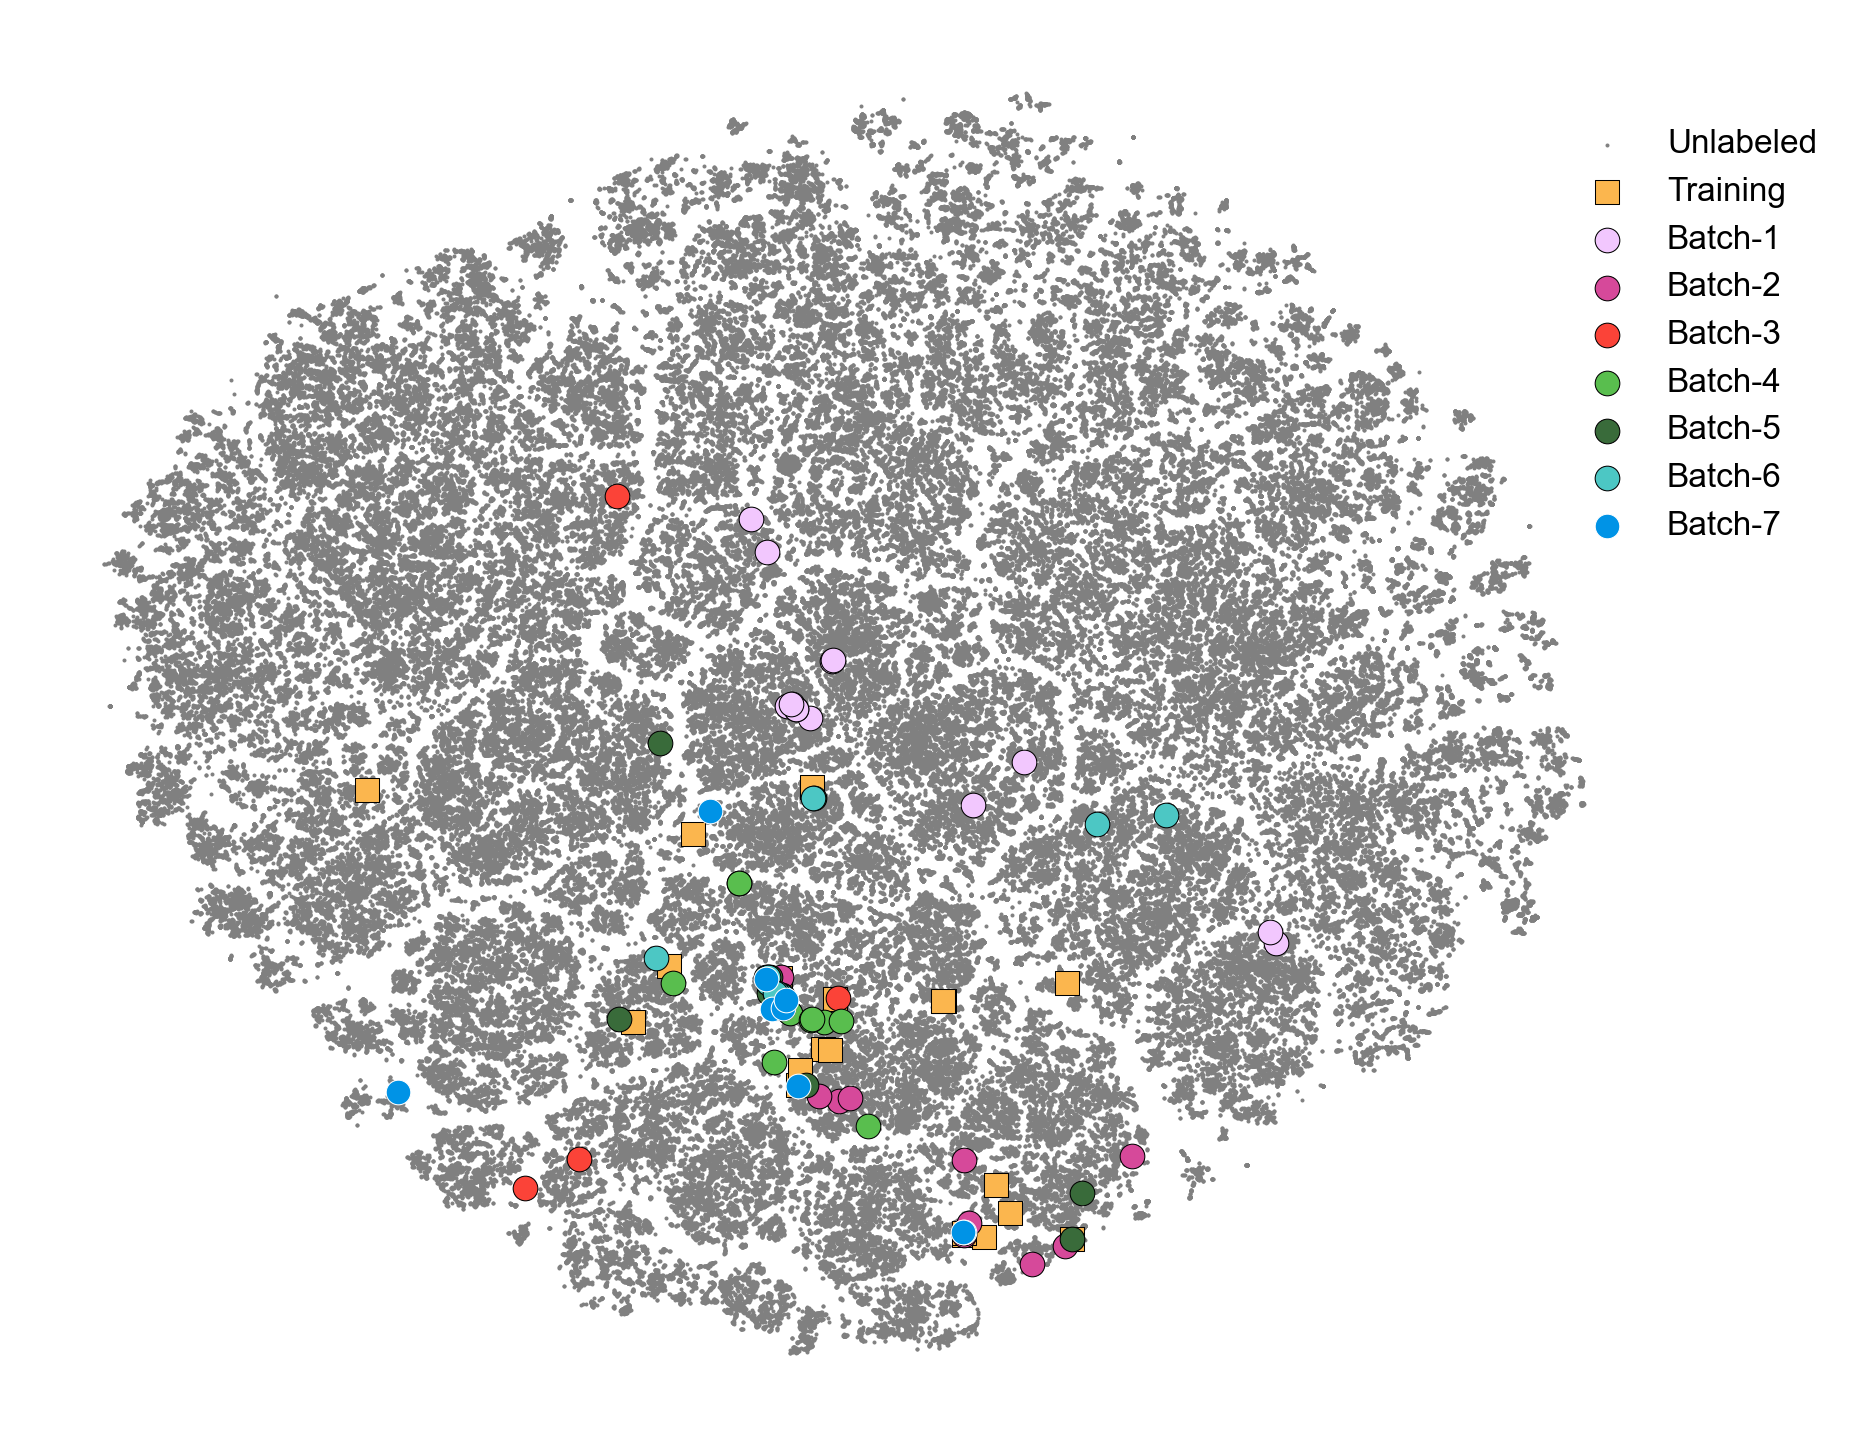

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
classes = df_tsne_['expt_test'].unique()
classes_names = ['Unlabeled', 'Training', 'Batch-1', 'Batch-2', 'Batch-3', 'Batch-4', 'Batch-5', 'Batch-6', 'Batch-7']
colors = ['gray', orange, pink, purple, red, green, c1, anvil, blue]
sizes = [0.5, 35, 35, 35, 35, 35, 35, 35, 35]
shapes = ['o', 's', 'o', 'o', 'o', 'o', 'o', 'o', 'o']
e_colors = [None, 'black', 'black', 'black', 'black', 'black', 'black', 'black', 'white']
l_widths = [0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25]
i=0
for cls in classes:
    df_cls = df_tsne_.loc[df_tsne_['expt_test'] == cls]
    ax.scatter(df_cls['tsne_0'], df_cls['tsne_1'], label=classes_names[i], alpha=1.0, color=colors[i], edgecolor=e_colors[i], linewidth=l_widths[i], s=sizes[i], marker=shapes[i])
    i += 1

plt.legend(bbox_to_anchor=(0.93, 0.95), loc='upper left', frameon=False)
plt.xticks([])
plt.yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

In [11]:
classes

array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.])